In [1]:
# epoch 在 EEG 中指时间窗口、时间片段
# 在 MNE 中，Epoch 对象是一种把连续型数据作为时间段集合的表示方法，形状为(n_events, n_channels, n_times)

In [8]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.utils.docs import ch_type

In [4]:
# 读取fif文件创建raw对象

# 拼接原始连续脑电/脑磁数据文件的完整路径
# 该文件包含滤波后的时序信号（0-40 Hz 带通）及通道元信息
raw_fname = '../data/sample_audvis_filt-0-40_raw.fif'
# 拼接事件标记文件的完整路径
# 该文件记录了实验中各类刺激或反应发生的时间点（sample index）及事件类型编码
event_fname = '../data/sample_audvis_filt-0-40_raw-eve.fif'

# 定义分段参数：
# event_id = 1   : 只选取事件编码为 1 的 trial（例如左侧听觉刺激）
# tmin = -0.2    : 每个 trial 截取刺激前 0.2 秒作为基线
# tmax = 0.5     : 每个 trial 截取刺激后 0.5 秒作为分析窗口
event_id, tmin, tmax = 1, -0.2, 0.5

raw = mne.io.read_raw_fif(raw_fname)
# 读取事件标记文件，返回 events 数组
# 形状为 (n_events, 3)，每行含义：[采样点索引, 0, 事件类型编码]
events = mne.read_events(event_fname)

Opening raw data file ../data/sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.


Not setting metadata
72 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 3)
3 projection items activated
Loading data for 72 events and 106 original time points ...
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 

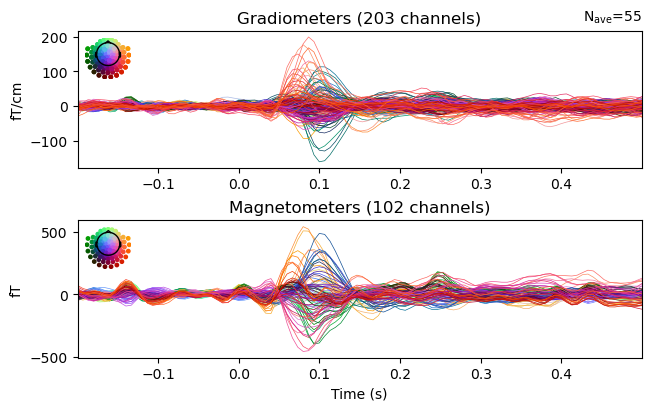

In [5]:
# 将两个已知存在噪声或故障的通道标记为坏通道（bad channels）
raw.info['bads'] += ['MEG 2443', 'EEG 053']

# 从 Raw 对象中挑选用于后续分析的通道
# meg=True     : 保留所有 MEG 通道（包括 grad 梯度计和 mag 磁力计）
# eeg=False    : 不保留 EEG 通道（因为当前主要关注 MEG 信号）
# stim=True    : 保留刺激（STIM）通道，用于确认事件标记
# eog=True     : 保留眼电（EOG）通道，用于后续眼动伪迹检查
# exclude='bads' : 自动排除上面标记的坏通道，以及 info 中已有的其他坏通道
picks = mne.pick_types(raw.info, meg=True, eeg=False, stim=True, eog=True, exclude='bads')

# 根据事件标记将连续数据切分为多个 epoch（试次/时段）
# raw, events    : 原始连续数据和事件标记数组
# event_id       : 只选取事件编码为 1 的 trial（例如左侧听觉刺激）
# tmin, tmax     : 每个 trial 的时间窗口，从刺激前 0.2 秒到刺激后 0.5 秒
# proj=True      : 自动应用已添加的 SSP（Signal Space Projection）投影，去除环境噪声/心跳等干扰
# picks          : 只使用上面挑选的通道
#
# baseline=(None, 0) : 基线校正，以每个 trial 从起始到 0 秒（刺激 onset）的均值作为基线，
#                      将整段数据减去该基线值，消除直流偏移和慢漂移
# preload=True   : 将 epoch 数据全部加载到内存中，便于后续快速操作和坏段剔除
# reject=...     : 根据各通道类型的峰值阈值自动剔除坏 trial：
#   grad=4000e-13 : MEG 梯度计阈值 4000 fT/cm
#   mag=4e-12     : MEG 磁力计阈值 4000 fT
#   eog=150e-6    : 眼电阈值 150 μV，若某 trial 中 EOG 超过此值则整段剔除
epochs = mne.Epochs(raw, events, event_id, tmin, tmax, proj=True, picks=picks,
                    baseline=(None, 0), preload=True, reject=dict(grad=4000e-13, mag=4e-12, eog=150e-6))

# 对所有保留下来的有效 epoch 按通道求平均，得到事件相关电位/场（ERP/ERF）
# evoked 对象包含每个通道在刺激后平均的时间-幅度波形。
evoked = epochs.average()

# 绘制平均后的 ERP/ERF 波形图，time_unit='s' 表示横轴时间单位使用秒（而不是毫秒）
evoked.plot(time_unit='s')
plt.show()

In [6]:
# 从零创建Epoch对象

In [9]:
sfreq = 100

data = np.random.randn(10, 5, sfreq * 2)

info = mne.create_info(
    ch_names=['MEG1', 'MEG2', 'EEG1', 'EEG2', 'EOG'],
    ch_types=['grad', 'grad', 'eeg', 'eeg', 'eog'],
    sfreq=sfreq,
)

# 三列数值分别是 起始采样点、当前事件来源的刺激通道的先前值、event_id
events = np.array([
    [0, 0, 1],
    [1, 0, 2],
    [2, 0, 1],
    [3, 0, 2],
    [4, 0, 1],
    [5, 0, 2],
    [6, 0, 1],
    [7, 0, 2],
    [8, 0, 1],
    [9, 0, 2],
])

# 微笑 1、皱眉 2
event_id = dict(smiling=1, frowning=2)

tmin = -0.1

custom_epochs = mne.EpochsArray(data, info=info, events=events, event_id=event_id)

Not setting metadata
10 matching events found
No baseline correction applied
0 projection items activated


In [10]:
print(custom_epochs)

<EpochsArray | 10 events (all good), 0 – 1.99 s (baseline off), ~88 KiB, data loaded,
 'smiling': 5
 'frowning': 5>


Need more than one channel to make topography for grad. Disabling interactivity.


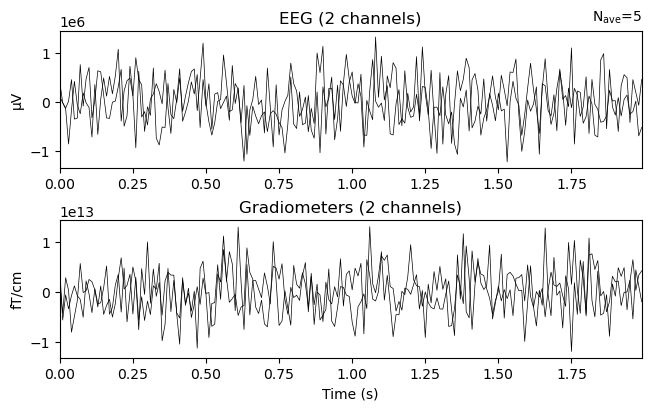

In [11]:
_ = custom_epochs['smiling'].average().plot(time_unit='s')

In [16]:
import mne
import numpy as np
import matplotlib.pyplot as plt

Not setting metadata
3 matching events found
No baseline correction applied
0 projection items activated
Using matplotlib as 2D backend.


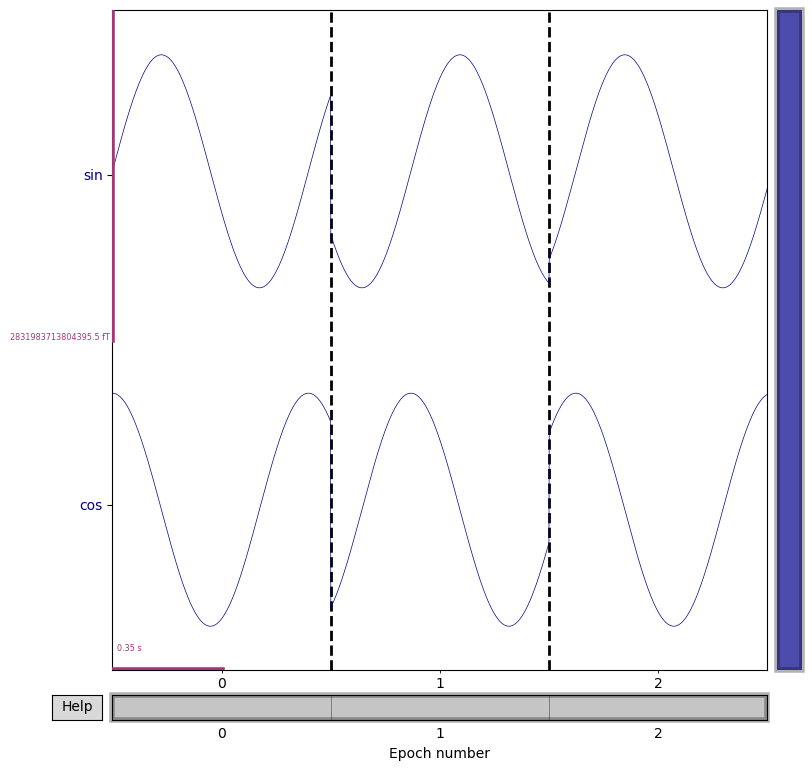

In [12]:
event_id = 1

# 手动构造事件标记数组，形状为 (n_events, 3)
# 每行含义：[采样点索引, 0（占位）, 事件类型编码]
# 三个事件分别发生在第 200、1200、2000 个采样点
events = np.array([[200, 0, event_id],
                   [1200, 0, event_id],
                   [2000, 0, event_id],])

# 采样频率：1000 Hz，即每毫秒一个采样点
sfreq = 1000

# 生成 10 秒的时间轴，步长 0.001 秒（对应 1000 Hz）
times = np.arange(0, 10, 0.001)

# 生成频率为 10 Hz 的正弦波和余弦波，作为模拟的 MEG 信号
sin = np.sin(times * 10)
cos = np.cos(times * 10)

# 手动构造 epoch 数据，形状为 (n_epochs, n_channels, n_times) = (3, 2, 700)
# 3 个 trial，每个 trial 包含 2 个通道，时长 700 个采样点（0.7 秒）
# 数据从正弦/余弦序列中按事件位置截取，模拟刺激后的信号片段
epochs_data = np.array([[sin[:700], cos[:700]],
                        [sin[1000:1700], cos[1000:1700]],
                        [sin[1800:2500], cos[1800:2500]]])

# 定义通道名称和类型
ch_names = ['sin', 'cos']
ch_types = ['mag', 'mag']

# 创建 Info 对象，描述通道元信息
info = mne.create_info(ch_names=ch_names, ch_types=ch_types, sfreq=sfreq)

# 用已有的 NumPy 数组构造 MNE Epochs 对象
# epochs_data : 形状为 (3, 2, 700) 的数据数组
# info        : 通道元信息
# events      : 事件标记数组，用于记录每个 trial 的发生时刻
# event_id    : 将编码 1 映射为标签 'arbitrary'
epochs = mne.EpochsArray(epochs_data, info=info, events=events, event_id={'arbitrary': event_id})

# 绘制 epoch 波形图，scalings='auto' 让 MNE 自动计算合适的幅度缩放比例
epochs.plot(scalings='auto')

# 显示图形窗口
plt.show()